Accuracy: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0
[[30  0]
 [ 0 50]]
rbc      0.212414
al       0.206692
htn      0.103640
sod      0.081627
bgr      0.067453
bu       0.065317
wc       0.064479
dm       0.057065
pc       0.042002
pot      0.027615
bp       0.024539
age      0.013929
su       0.008974
appet    0.008368
pe       0.006065
dtype: float64


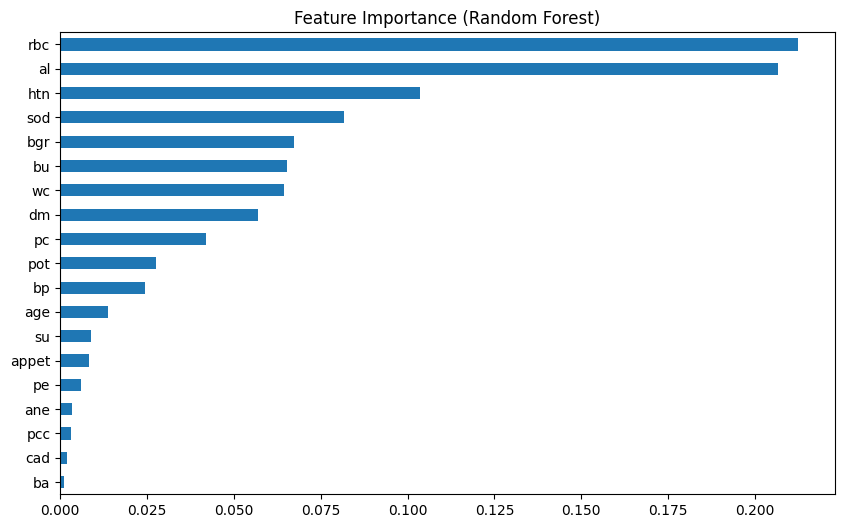

In [1]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы

chronic_kidney_disease_2 = pd.read_csv('/Users/konstantingeneralov/IDE/Data/chronic_kidney_disease_preprocessed.csv', sep=',')
ckd_11 = chronic_kidney_disease_2.copy()
# удалим самые коррелирующие признаки, так как они могут вносить шум в модель и ухудшать ее обобщающую способность.
ckd_10=ckd_11.copy()
ckd_10.drop(columns=['hemo', 'pcv', 'sg', 'rc','sc'], inplace=True)


# Подготовка данных для моделей. Разделим данные на признаки X и целевую переменную y.

X = ckd_10.drop(columns=['class'])
y = ckd_10['class']

# Разделение train / test.  stratify=y Чтобы сохранить долю CKD / notCKD.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Выберем 3 модели для классификации: Logistic Regression, Random Forest и Gradient Boosting. Обучение с кросс-валидацией. Модель обучается 5 раз на разных подвыборках.
# Это защищает от случайного результата.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
# первую будем делать логистическую регрессию
# так как данные разные нужно стандартизировать числовые признаки для логистической регрессии, так как она чувствительна к масштабу данных.
from sklearn.preprocessing import StandardScaler

# random forest

rf = RandomForestClassifier(
    n_estimators=300,      # количество деревьев
    max_depth=None,        # глубина (None = до чистоты)
    random_state=42,
    class_weight='balanced' # важно для медицины
)

rf.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
# Предсказания
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print(confusion_matrix(y_test, y_pred_rf))

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)
print(importances.sort_values(ascending=False).head(15))
importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.show()